# Notebook 5: Creator Segmentation & Explainability

**Business problem:** Which type of creator should a brand partner with for their campaign?
There is no one-size-fits-all answer — this notebook identifies four distinct creator segments
and explains what drives performance within each one.

**Methods used:**
- PCA (14 components → 90% variance explained)
- Hierarchical clustering (Ward linkage) to validate K
- K-Means (K=4, silhouette=0.251)
- Random Forest classifier + SHAP values per cluster per target metric

**Four creator segments identified:**
- Cluster 0: Mixed/Balanced — consistency over optimisation
- Cluster 1: Tech-Micro-Explicit — transparency performers, highest engagement
- Cluster 2: Lifestyle-Organic-Blend — trust builders, highest sentiment + growth
- Cluster 3: Tech-Macro-Implicit — diminishing returns, worst on all metrics


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import scipy.cluster.hierarchy as sch
import shap
from sklearn.metrics import classification_report

DATA_DIR = 'C:\\Users\\sagri\\Documents\\GitHub\\Projects\\InfluencerMarketingAnalytics\\data\\'
master_data = pd.read_csv(DATA_DIR + 'master_data_27Jul.csv')
master_data['publishedAt'] = pd.to_datetime(master_data['publishedAt'], errors='coerce')
print('master_data shape:', master_data.shape)


master_data shape: (2338, 80)


**RESEARCH 5**

In [2]:
channel = pd.read_csv("C:/Users/sagri/Documents/GitHub/Projects/InfluencerMarketingAnalytics/data/channel_data.csv")
channel.columns

Index(['channelId', 'name', 'genre', 'sizeCategory', 'title', 'channelUrl',
       'channelCreationDate', 'videosInLast6Months', 'videoCount', 'viewCount',
       'description', 'country', 'channel_age_years', 'traditional_videos_6mo',
       'shorts_videos_6mo', 'total_videos_6mo', 'pct_traditional_12mo',
       'pct_shorts_6mo', 'uploads_per_month_traditional',
       'pct_recent_uploads_traditional', 'avg_views_per_video',
       'avg_views_traditional_12mo', 'subscriber_growth_pct', 'log_videoCount',
       'log_viewCount', 'log_traditional_videos_12mo', 'log_shorts_videos_6mo',
       'num_sponsored_videos', 'num_explicit_videos', 'num_implicit_videos',
       'num_organic_videos', 'first_sponsor_date_channel',
       'has_sponsorship_history', 'pct_sponsored', 'pct_explicit',
       'pct_implicit', 'pct_organic', 'mean_viewCount', 'median_viewCount',
       'mean_likeCount', 'mean_commentCount', 'mean_total_engagement_rate',
       'mean_sentiment_score', 'dominant_sentiment_chan

In [3]:
data = pd.read_csv('C:\\Users\\sagri\\Documents\\GitHub\\Projects\\InfluencerMarketingAnalytics\\data\\master_data.csv')

In [4]:
#Feature Selection for PCA
df6 = data.copy()

features = [
    # Engagement/Sentiment
    'total_engagement_rate', 'mean_sentiment_score', 'std_sentiment_score', 'median_sentiment_score', 'like_engagement_rate', 'comment_engagement_rate', 'mean_total_engagement_rate',
    # Video/Channel activity
    'uploads_per_month_traditional', 'duration_min', 'title_len', 'description_len',
    'pct_sponsored', 'pct_explicit', 'pct_implicit', 'pct_organic', 'IsSponsored',
    'upload_hour', 'year_month', 'Sponsorship', 'first_sponsor_date', 'is_pre_sponsor',
    'videos_since_first_sponsor', 'pct_positive', 'pct_neutral', 'pct_negative',
    'pct_recent_uploads_traditional', 'avg_views_traditional_12mo', 'pscore',
    # Audience and platform stats
    'viewCount_per_day', 'likeCount_per_day', 'commentCount_per_day',
    # Channel size/age
    'sizeCategory', 'channel_age_years', 'genre', 'country',
    # profiles
    'viewCount_rolling5_mean', 'likeCount_rolling5_mean', 'commentCount_rolling5_mean', 'sponsored_rolling5',
    'viewCount', 'likeCount', 'has_sponsorship_history', 'log_subs_27Jul', 'daily_subs_growth_pct', 'r_daily_compound', 'pre5_engage'
]

df6 = df6[features].copy()

In [5]:
# Handle date columns
if 'first_sponsor_date' in df6.columns:
    df6['first_sponsor_date'] = pd.to_datetime(df6['first_sponsor_date'], errors='coerce')
    min_date = df6['first_sponsor_date'].min()
    df6['first_sponsor_days'] = (df6['first_sponsor_date'] - min_date).dt.days
    df6.drop(columns=['first_sponsor_date'], inplace=True)

if 'year_month' in df6.columns:
    # if it's string, convert to datetime
    df6['year_month'] = pd.to_datetime(df6['year_month'], errors='coerce')
    df6['upload_month'] = df6['year_month'].dt.month
    df6['upload_year'] = df6['year_month'].dt.year
    df6.drop(columns=['year_month'], inplace=True)

In [6]:
# ------------------ 2. SETUP CATEGORICALS/NUMERICS ------------------
categorical = [
    'Sponsorship', 'sizeCategory', 'genre', 'country'
]
# Ensure correct dtype for categoricals
for c in categorical:
    if c in df6.columns:
        df6[c] = df6[c].astype('category')

# Binary/flag columns to float
for col in ['is_pre_sponsor', 'has_sponsorship_history', 'IsSponsored']:
    if col in df6.columns:
        df6[col] = df6[col].astype(float)

# Replace any remaining bool with float (just in case)
for col in df6.columns:
    if df6[col].dtype == bool:
        df6[col] = df6[col].astype(float)

# Fill NAs (numerics as median, categoricals as mode)
for c in df6.columns:
    if df6[c].dtype.name == 'category':
        df6[c] = df6[c].cat.add_categories('Unknown').fillna('Unknown')
    elif pd.api.types.is_numeric_dtype(df6[c]):
        df6[c] = df6[c].fillna(df6[c].median())
    else:
        df6[c] = df6[c].fillna(0)


In [7]:
# ------------------ 3. ONE HOT ENCODE & STANDARDIZE ------------------
numerics = df6.columns.difference(categorical)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerics),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical)
    ]
)
print("Numerics:", numerics)
print("Categorical:", categorical)
print("df6 shape before preprocess:", df6.shape)
X_preprocessed = preprocessor.fit_transform(df6)

# To get feature names after transform
cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical)
all_feature_names = list(numerics) + list(cat_names)

Numerics: Index(['IsSponsored', 'avg_views_traditional_12mo', 'channel_age_years',
       'commentCount_per_day', 'commentCount_rolling5_mean',
       'comment_engagement_rate', 'daily_subs_growth_pct', 'description_len',
       'duration_min', 'first_sponsor_days', 'has_sponsorship_history',
       'is_pre_sponsor', 'likeCount', 'likeCount_per_day',
       'likeCount_rolling5_mean', 'like_engagement_rate', 'log_subs_27Jul',
       'mean_sentiment_score', 'mean_total_engagement_rate',
       'median_sentiment_score', 'pct_explicit', 'pct_implicit',
       'pct_negative', 'pct_neutral', 'pct_organic', 'pct_positive',
       'pct_recent_uploads_traditional', 'pct_sponsored', 'pre5_engage',
       'pscore', 'r_daily_compound', 'sponsored_rolling5',
       'std_sentiment_score', 'title_len', 'total_engagement_rate',
       'upload_hour', 'upload_month', 'upload_year',
       'uploads_per_month_traditional', 'videos_since_first_sponsor',
       'viewCount', 'viewCount_per_day', 'viewCount_r

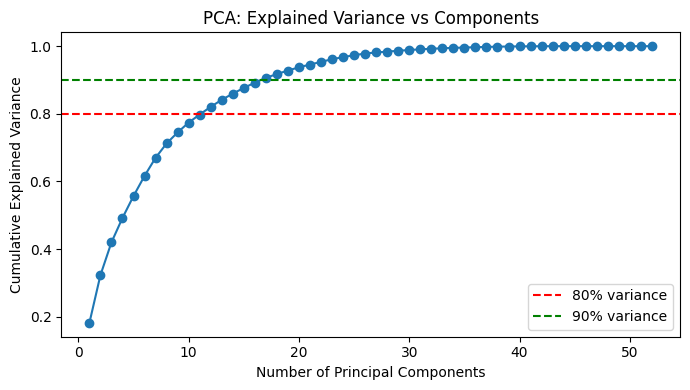

Selected number of components for PCA: 14
X_preprocessed shape: (2308, 52)


In [8]:
# PCA

# How many components? Let's try enough to explain 80–90% variance
pca = PCA()
X_pca = pca.fit_transform(X_preprocessed)

# Scree plot: how much variance is explained by each component?
explained = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(7,4))
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Explained Variance vs Components')
plt.axhline(0.8, color='r', linestyle='--', label='80% variance')
plt.axhline(0.9, color='g', linestyle='--', label='90% variance')
plt.legend()
plt.tight_layout()
plt.show()


# Choose components explaining ~80-90% variance
n_components = np.argmax(explained >= 0.85) + 1
print(f"Selected number of components for PCA: {n_components}")

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_preprocessed)

print("X_preprocessed shape:", X_preprocessed.shape)

In [9]:
# PCA Explained Variance and Loadings

# If you have the PCA object (pca) and feature names:
explained_variance = pca.explained_variance_ratio_
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var*100:.2f}% variance explained")

PC1: 18.15% variance explained
PC2: 14.11% variance explained
PC3: 9.71% variance explained
PC4: 7.23% variance explained
PC5: 6.47% variance explained
PC6: 5.96% variance explained
PC7: 5.35% variance explained
PC8: 4.25% variance explained
PC9: 3.26% variance explained
PC10: 2.91% variance explained
PC11: 2.38% variance explained
PC12: 2.29% variance explained
PC13: 2.06% variance explained
PC14: 1.83% variance explained


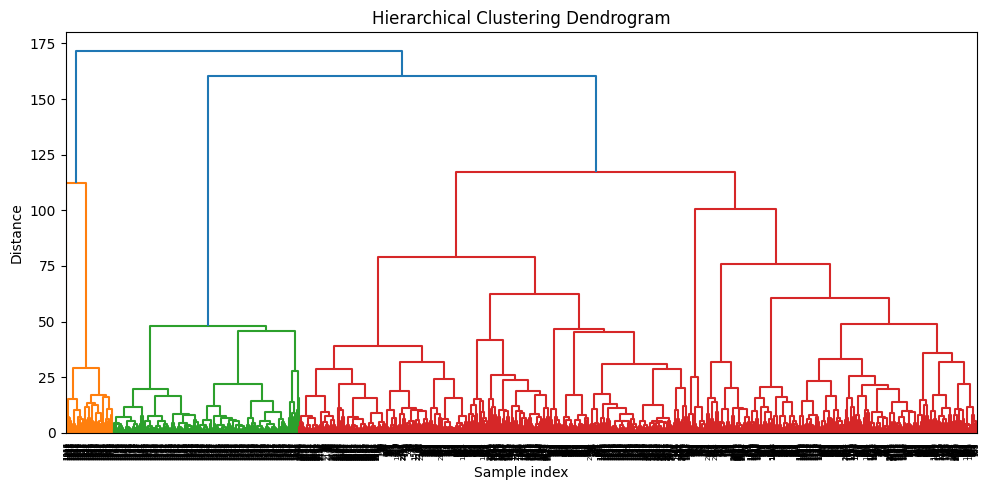

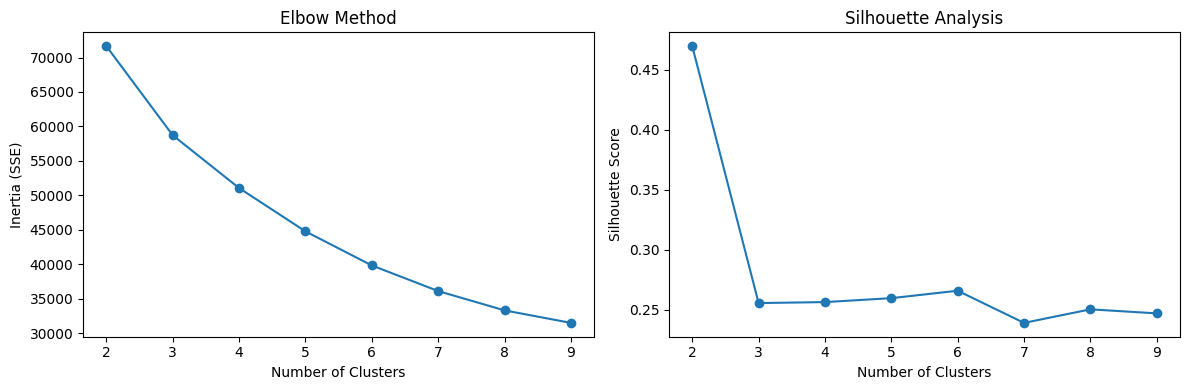

Optimal number of clusters by silhouette: 2


In [10]:
#Hierarchical clsutering to figure out the number of clusters

# Dendrogram to visually choose cluster number
plt.figure(figsize=(10,5))
dendrogram = sch.dendrogram(sch.linkage(X_pca, method='ward'))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Verifying using Elbow and Silhouette to choose K
sse = []
silhouette = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    preds = km.fit_predict(X_pca)
    sse.append(km.inertia_)
    silhouette.append(silhouette_score(X_pca, preds))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(k_range, sse, 'o-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(k_range, silhouette, 'o-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(silhouette)]
print(f"Optimal number of clusters by silhouette: {optimal_k}")


K=2: Silhouette score = 0.470

Cluster sizes for K=2:
 1    2187
0     121
Name: count, dtype: int64

Cluster vs. Genre for K=2:
 genre  Lifestyle  Tech
row_0                 
0              0   121
1            817  1370

Cluster vs. SizeCategory for K=2:
 sizeCategory  Macro  Micro  Nano
row_0                           
0               121      0     0
1               555   1254   378

Cluster vs. Sponsorship Type for K=2:
 Sponsorship  Explicit  Implicit  Organic
row_0                                   
0                  19        83       19
1                1189       540      458

Mean summary for K=2:
            total_engagement_rate  mean_sentiment_score  like_engagement_rate  \
cluster_2                                                                      
0                          0.033                 0.772                 0.031   
1                          0.069                 0.838                 0.064   

           comment_engagement_rate  pct_sponsored  pct_expli

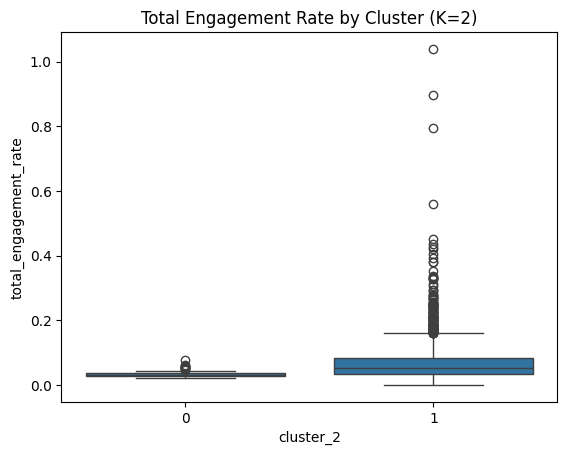

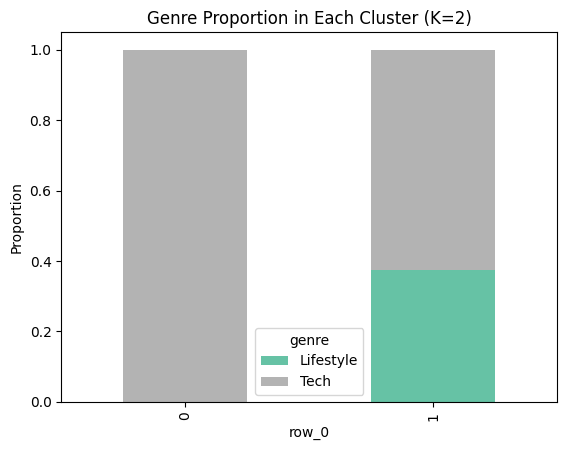


K=3: Silhouette score = 0.255

Cluster sizes for K=3:
 1    1712
0     475
2     121
Name: count, dtype: int64

Cluster vs. Genre for K=3:
 genre  Lifestyle  Tech
row_0                 
0              7   468
1            810   902
2              0   121

Cluster vs. SizeCategory for K=3:
 sizeCategory  Macro  Micro  Nano
row_0                           
0                 0    468     7
1               555    786   371
2               121      0     0

Cluster vs. Sponsorship Type for K=3:
 Sponsorship  Explicit  Implicit  Organic
row_0                                   
0                 439        15       21
1                 750       525      437
2                  19        83       19

Mean summary for K=3:
            total_engagement_rate  mean_sentiment_score  like_engagement_rate  \
cluster_3                                                                      
0                          0.145                 0.836                 0.137   
1                          0.048  

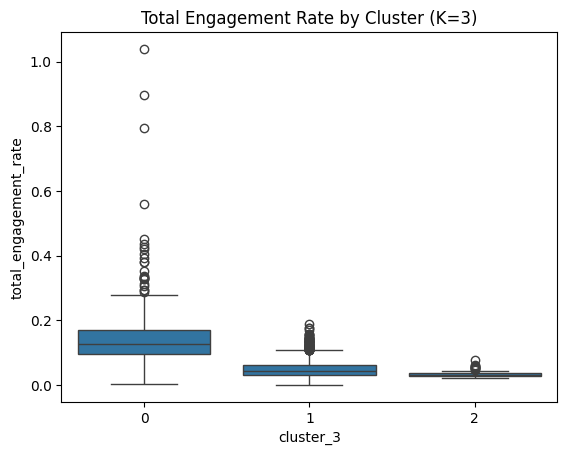

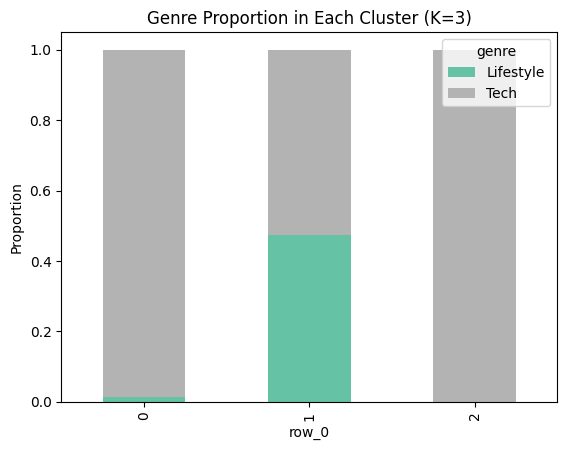


K=4: Silhouette score = 0.256

Cluster sizes for K=4:
 1    1087
3     627
2     473
0     121
Name: count, dtype: int64

Cluster vs. Genre for K=4:
 genre  Lifestyle  Tech
row_0                 
0              0   121
1            254   833
2              5   468
3            558    69

Cluster vs. SizeCategory for K=4:
 sizeCategory  Macro  Micro  Nano
row_0                           
0               121      0     0
1               329    621   137
2                 0    468     5
3               226    165   236

Cluster vs. Sponsorship Type for K=4:
 Sponsorship  Explicit  Implicit  Organic
row_0                                   
0                  19        83       19
1                 581       322      184
2                 438        14       21
3                 170       204      253

Mean summary for K=4:
            total_engagement_rate  mean_sentiment_score  like_engagement_rate  \
cluster_4                                                                      
0      

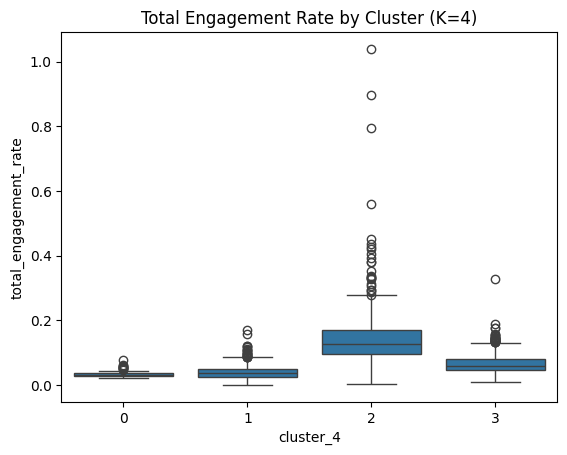

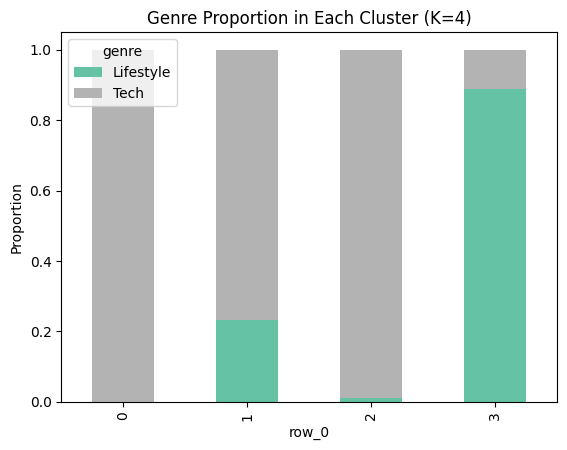

In [11]:
# Try KMeans with 2, 3, and 4 clusters
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    cluster_labels = km.fit_predict(X_pca)
    df6[f'cluster_{k}'] = cluster_labels
    sil = silhouette_score(X_pca, cluster_labels)
    print(f"\nK={k}: Silhouette score = {sil:.3f}")

    # --- Profiling Clusters ---
    print(f"\nCluster sizes for K={k}:\n", pd.Series(cluster_labels).value_counts())

    # Example: cross-tab genre and size
    print(f"\nCluster vs. Genre for K={k}:\n", pd.crosstab(cluster_labels, df6['genre']))
    print(f"\nCluster vs. SizeCategory for K={k}:\n", pd.crosstab(cluster_labels, df6['sizeCategory']))
    print(f"\nCluster vs. Sponsorship Type for K={k}:\n", pd.crosstab(cluster_labels, df6['Sponsorship']))

    # Summary stats for key numeric features
    numeric_cols = [
        'total_engagement_rate', 'mean_sentiment_score', 'like_engagement_rate',
        'comment_engagement_rate', 'pct_sponsored', 'pct_explicit', 'pct_implicit',
        'pct_organic', 'IsSponsored', 'daily_subs_growth_pct'
    ]
    print(f"\nMean summary for K={k}:\n", df6.groupby(f'cluster_{k}')[numeric_cols].mean().round(3))

    # Visualization: Example boxplot for engagement rate by cluster
    sns.boxplot(x=f'cluster_{k}', y='total_engagement_rate', data=df6)
    plt.title(f'Total Engagement Rate by Cluster (K={k})')
    plt.show()

    # Visualization: Cluster composition for genre (stacked bar)
    genre_counts = pd.crosstab(cluster_labels, df6['genre'], normalize='index')
    genre_counts.plot(kind='bar', stacked=True, colormap='Set2')
    plt.title(f'Genre Proportion in Each Cluster (K={k})')
    plt.ylabel('Proportion')
    plt.show()


==== Visualisations for K=3 ====


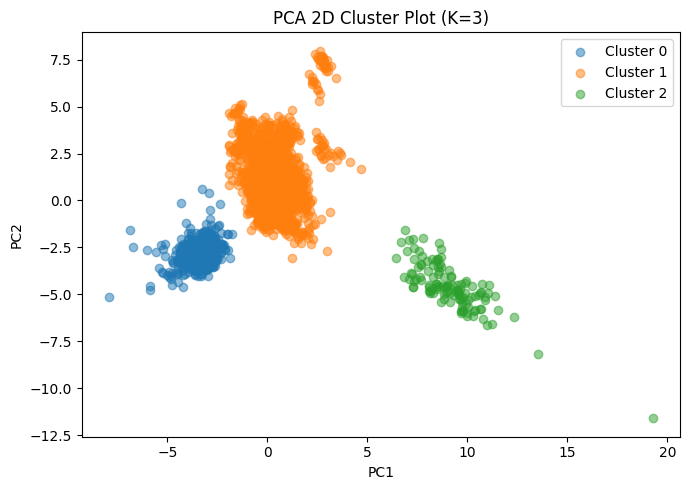

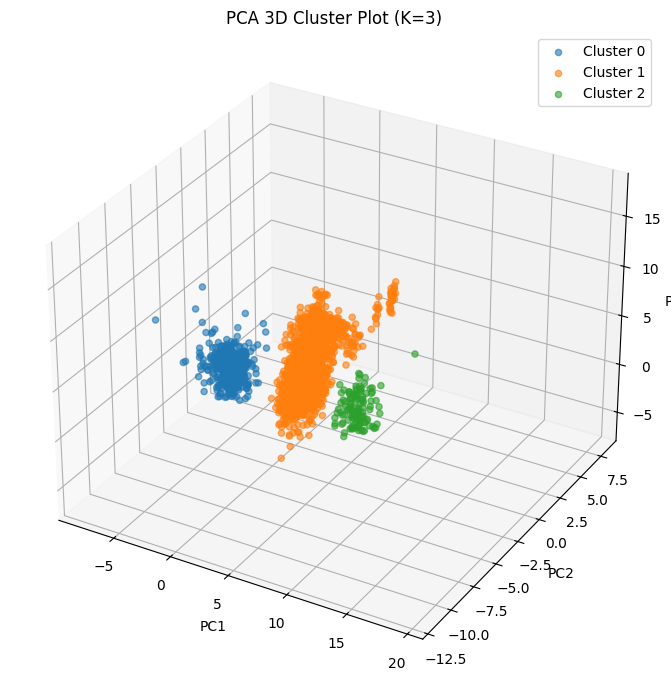

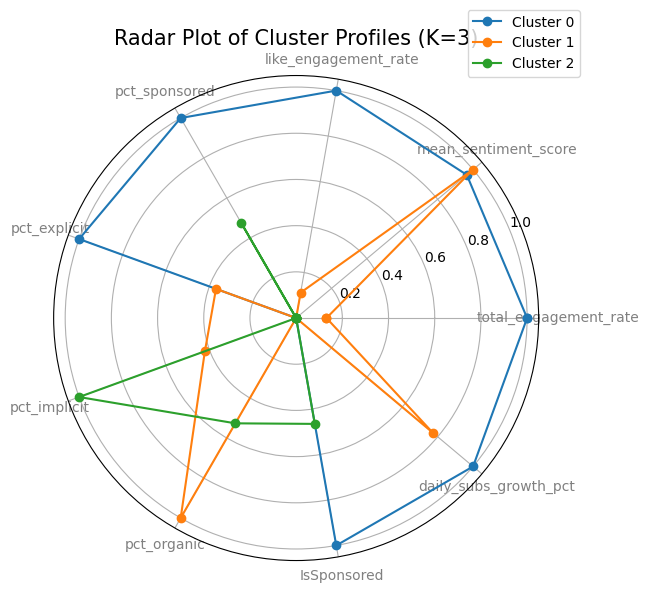

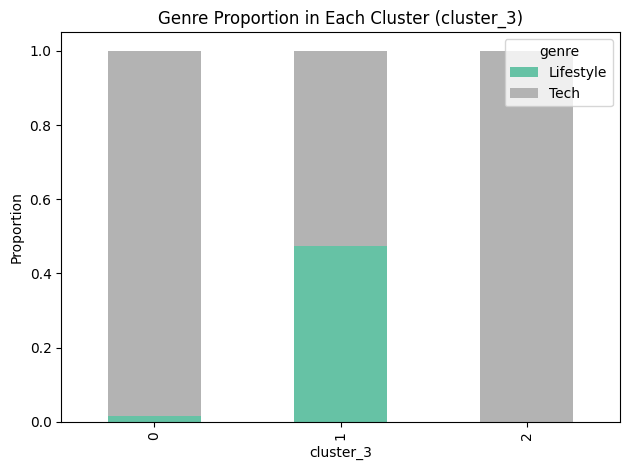

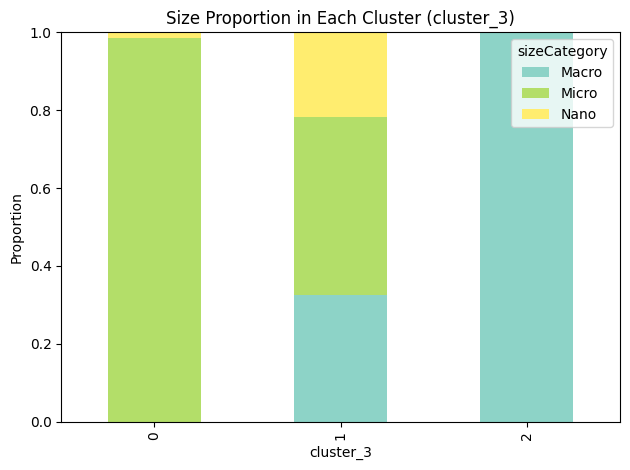

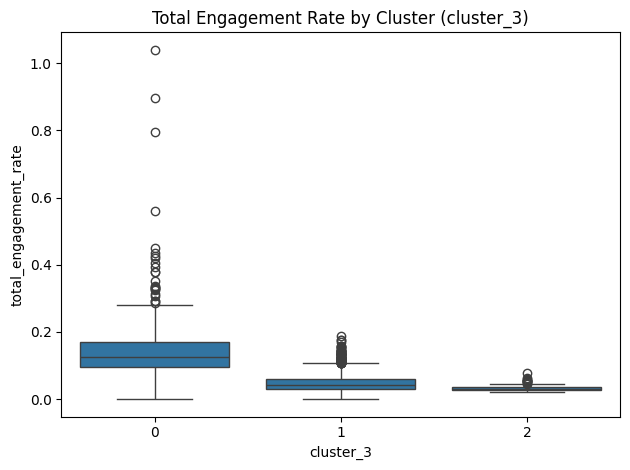


==== Visualisations for K=4 ====


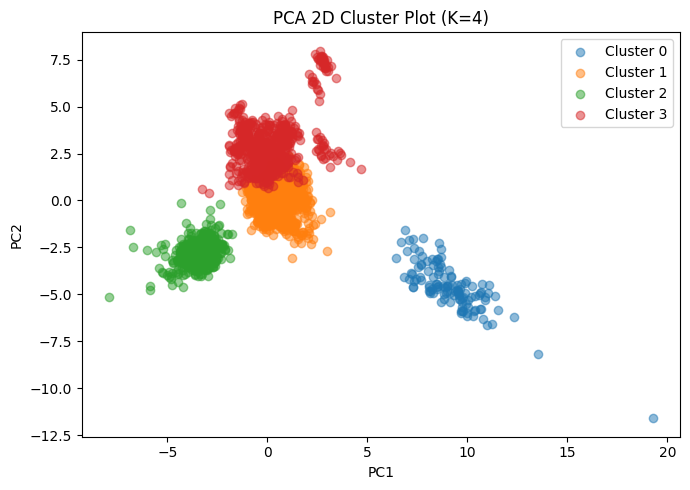

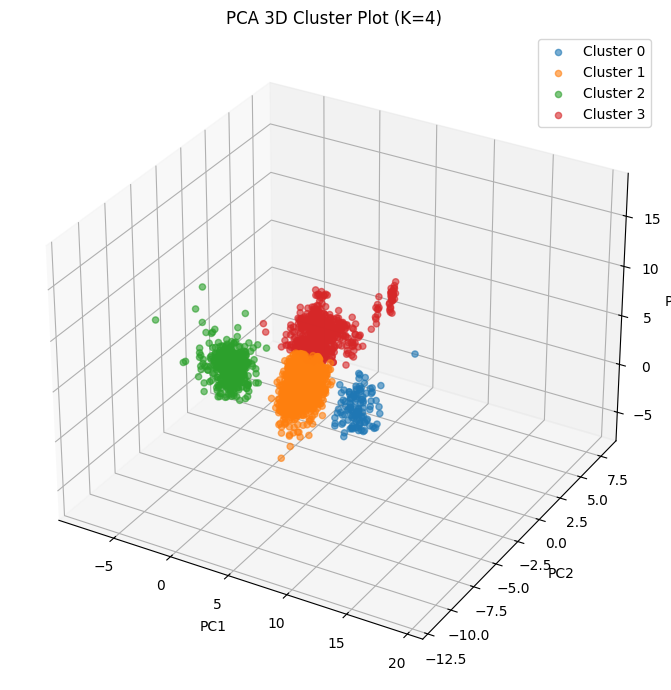

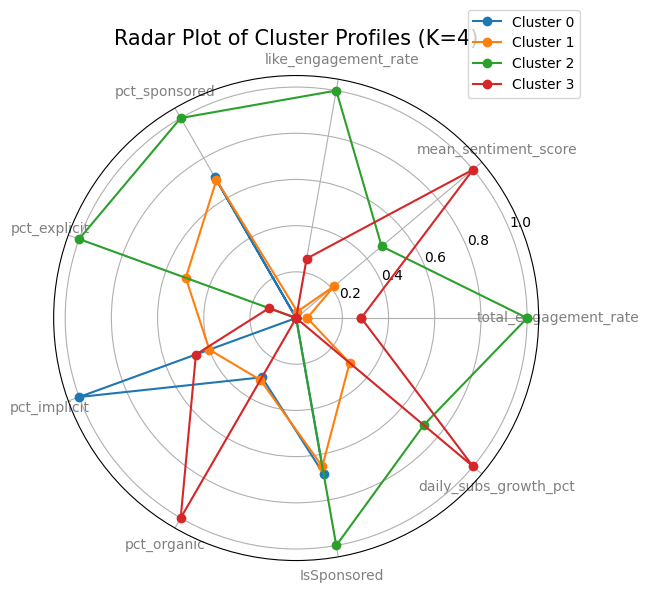

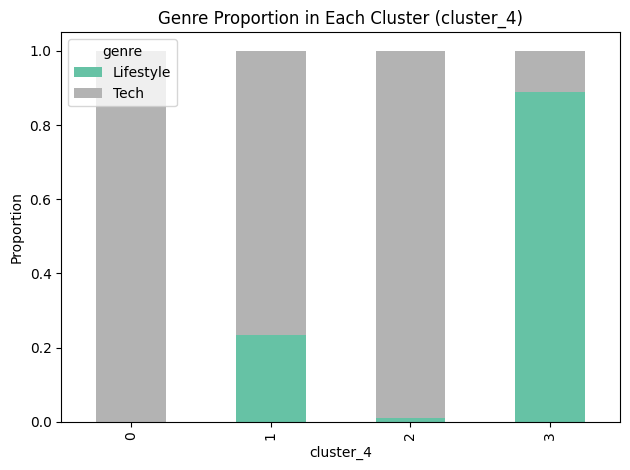

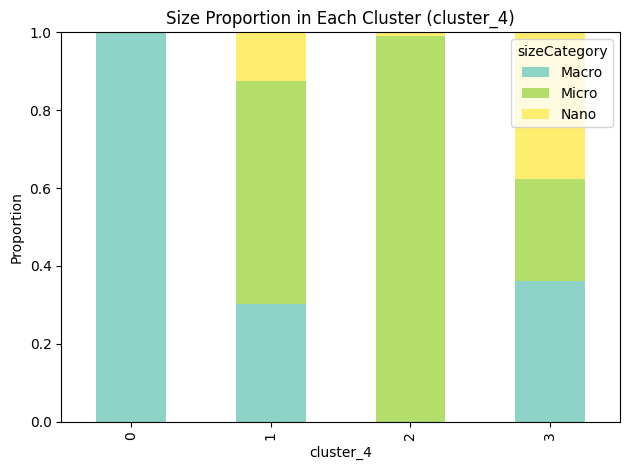

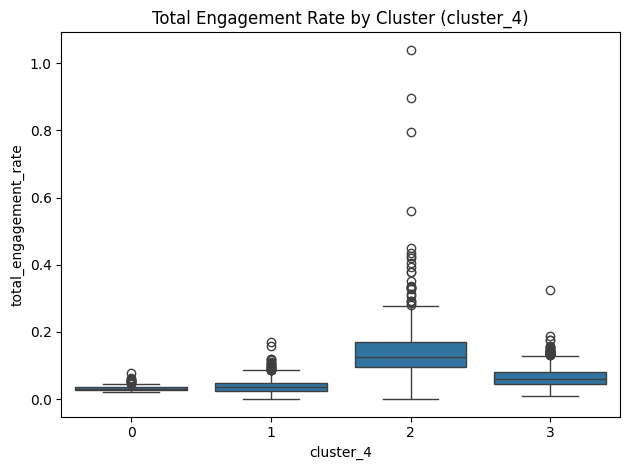

In [12]:
from mpl_toolkits.mplot3d import Axes3D


# ============ 1. 2D and 3D PCA Cluster Plots ============

def plot_pca_2d(X_pca, labels, k):
    plt.figure(figsize=(7,5))
    for cluster in range(k):
        plt.scatter(X_pca[labels==cluster, 0], X_pca[labels==cluster, 1], label=f'Cluster {cluster}', alpha=0.5)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'PCA 2D Cluster Plot (K={k})')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_pca_3d(X_pca, labels, k):
    fig = plt.figure(figsize=(9,7))
    ax = fig.add_subplot(111, projection='3d')
    for cluster in range(k):
        ax.scatter(X_pca[labels==cluster, 0], X_pca[labels==cluster, 1], X_pca[labels==cluster, 2], label=f'Cluster {cluster}', alpha=0.6)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    plt.title(f'PCA 3D Cluster Plot (K={k})')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ============ 2. Radar/Spider Plots for Cluster Profiles ============

radar_features = [
    'total_engagement_rate', 'mean_sentiment_score', 'like_engagement_rate',
    'pct_sponsored', 'pct_explicit', 'pct_implicit', 'pct_organic',
    'IsSponsored', 'daily_subs_growth_pct'
]

def radar_plot(data, labels, title):
    categories = list(data.columns)
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    plt.figure(figsize=(8, 6))
    for idx, row in data.iterrows():
        values = row.tolist() + row.tolist()[:1]
        plt.polar(angles, values, marker='o', label=f'{labels} {idx}')
    plt.xticks(angles[:-1], categories, color='grey', size=10)
    plt.title(title, size=15)
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.15))
    plt.tight_layout()
    plt.show()

# ============ 3. Stacked Bar (Genre and Size) & Boxplots ============

def cluster_barplots(df, cluster_col):
    # Genre stacked bar
    genre_counts = pd.crosstab(df[cluster_col], df['genre'], normalize='index')
    genre_counts.plot(kind='bar', stacked=True, colormap='Set2')
    plt.title(f'Genre Proportion in Each Cluster ({cluster_col})')
    plt.ylabel('Proportion')
    plt.tight_layout()
    plt.show()
    # Size stacked bar
    size_counts = pd.crosstab(df[cluster_col], df['sizeCategory'], normalize='index')
    size_counts.plot(kind='bar', stacked=True, colormap='Set3')
    plt.title(f'Size Proportion in Each Cluster ({cluster_col})')
    plt.ylabel('Proportion')
    plt.tight_layout()
    plt.show()
    # Engagement boxplot
    sns.boxplot(x=cluster_col, y='total_engagement_rate', data=df)
    plt.title(f'Total Engagement Rate by Cluster ({cluster_col})')
    plt.tight_layout()
    plt.show()

# ================= RUN FOR BOTH K=3 and K=4 ====================

for k, cluster_col in zip([3,4], ['cluster_3', 'cluster_4']):
    print(f"\n==== Visualisations for K={k} ====")
    # 2D and 3D PCA plots
    plot_pca_2d(X_pca, df6[cluster_col].values, k)
    plot_pca_3d(X_pca, df6[cluster_col].values, k)

    # Radar/Spider plot for cluster means (scaled)
    cluster_means = df6.groupby(cluster_col)[radar_features].mean()
    cluster_means_scaled = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
    radar_plot(cluster_means_scaled, f'Cluster', f'Radar Plot of Cluster Profiles (K={k})')

    # Barplots for genre/size, boxplot for engagement
    cluster_barplots(df6, cluster_col)


In [13]:
# Suppose n_components is your chosen number of components
for i in range(X_pca.shape[1]):
    df6[f'pca{i+1}'] = X_pca[:, i]


df6.columns

Index(['total_engagement_rate', 'mean_sentiment_score', 'std_sentiment_score',
       'median_sentiment_score', 'like_engagement_rate',
       'comment_engagement_rate', 'mean_total_engagement_rate',
       'uploads_per_month_traditional', 'duration_min', 'title_len',
       'description_len', 'pct_sponsored', 'pct_explicit', 'pct_implicit',
       'pct_organic', 'IsSponsored', 'upload_hour', 'Sponsorship',
       'is_pre_sponsor', 'videos_since_first_sponsor', 'pct_positive',
       'pct_neutral', 'pct_negative', 'pct_recent_uploads_traditional',
       'avg_views_traditional_12mo', 'pscore', 'viewCount_per_day',
       'likeCount_per_day', 'commentCount_per_day', 'sizeCategory',
       'channel_age_years', 'genre', 'country', 'viewCount_rolling5_mean',
       'likeCount_rolling5_mean', 'commentCount_rolling5_mean',
       'sponsored_rolling5', 'viewCount', 'likeCount',
       'has_sponsorship_history', 'log_subs_27Jul', 'daily_subs_growth_pct',
       'r_daily_compound', 'pre5_engage

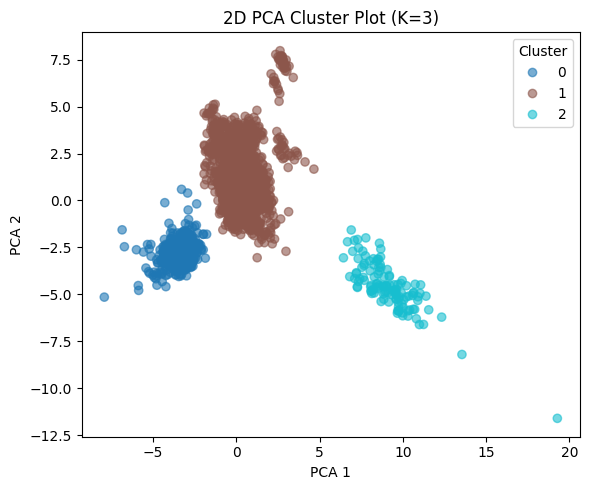

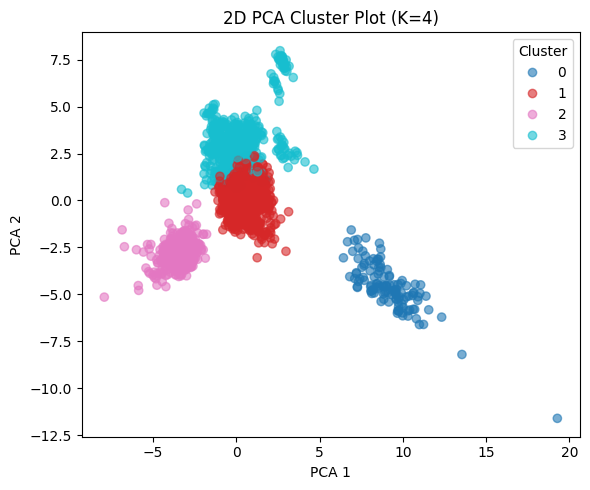

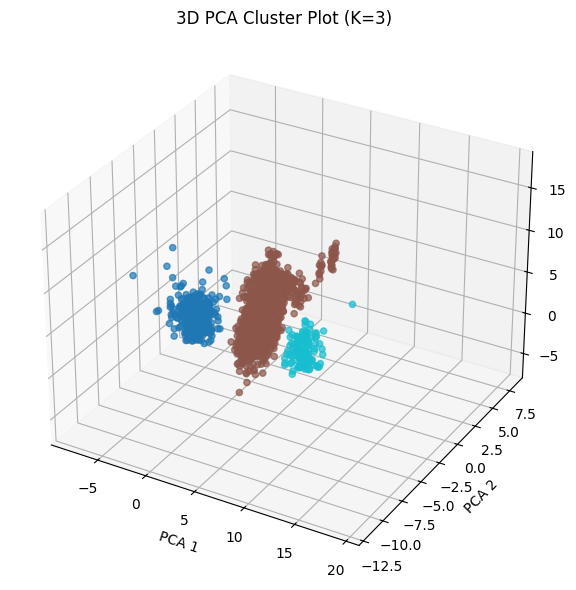

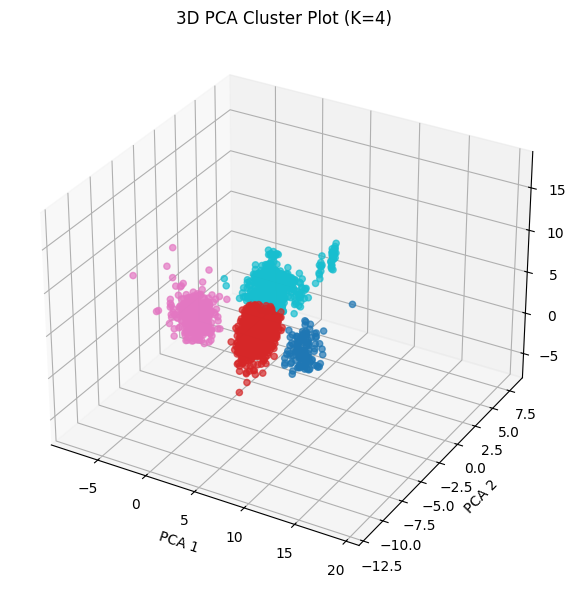

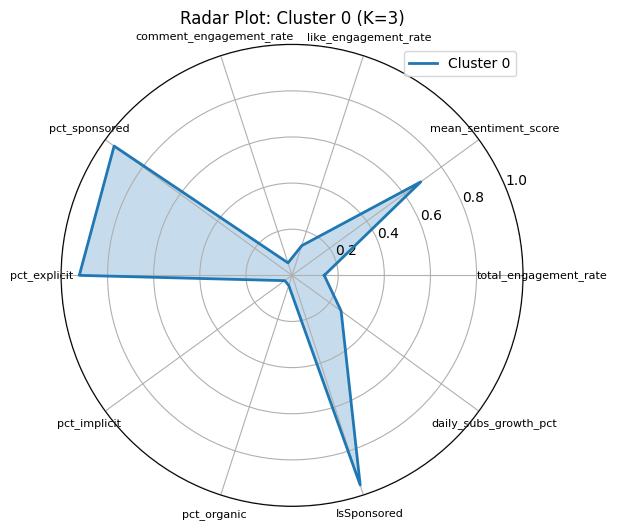

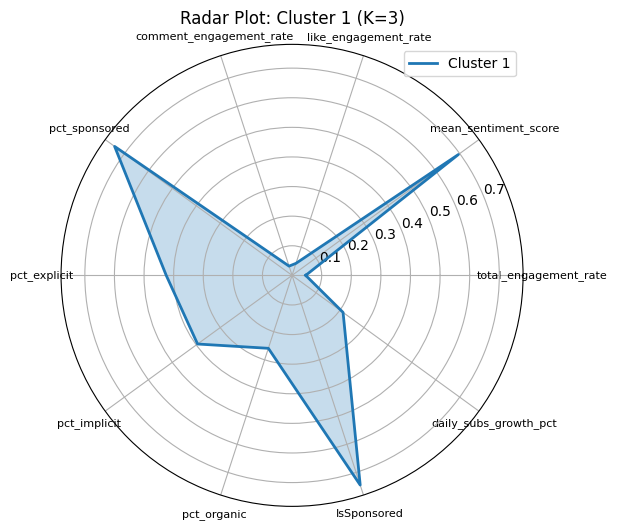

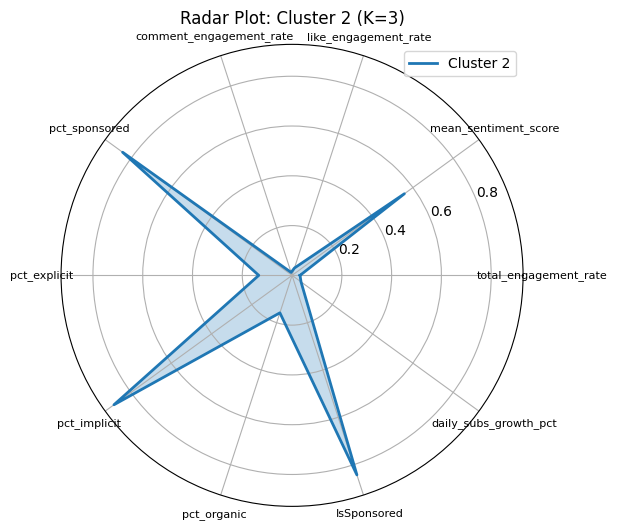

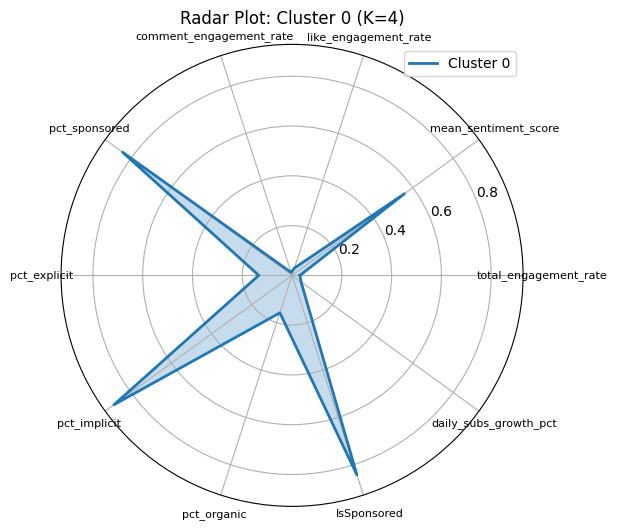

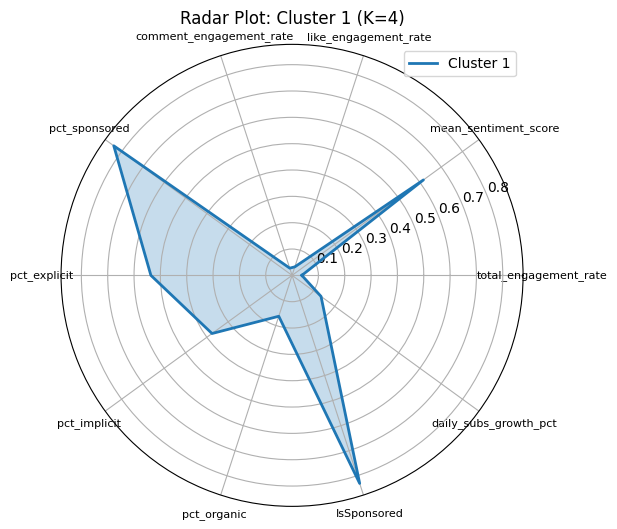

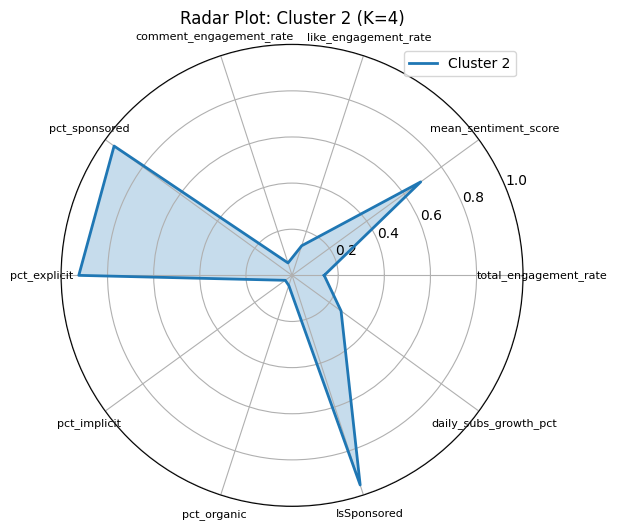

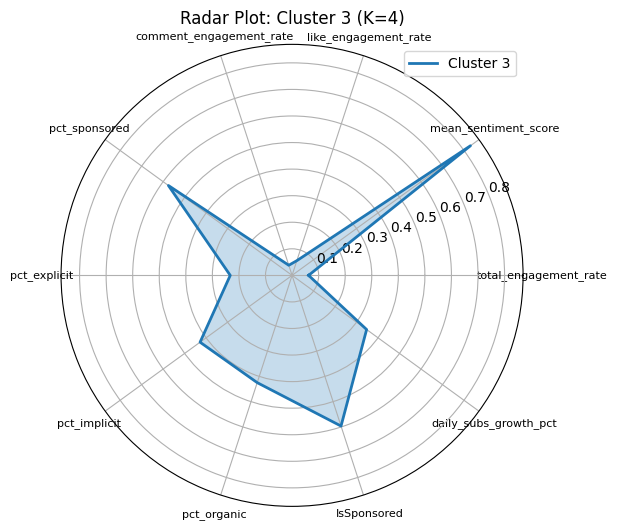

In [14]:
for k in [3, 4]:
    cluster_col = f'cluster_{k}'
    plt.figure(figsize=(6,5))
    scatter = plt.scatter(df6['pca1'], df6['pca2'], c=df6[cluster_col], cmap='tab10', alpha=0.6)
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.title(f'2D PCA Cluster Plot (K={k})')
    plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.tight_layout()
    plt.show()


# 3D (requires at least 3 PCs)
from mpl_toolkits.mplot3d import Axes3D
for k in [3, 4]:
    cluster_col = f'cluster_{k}'
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(df6['pca1'], df6['pca2'], df6['pca3'], c=df6[cluster_col], cmap='tab10', alpha=0.7)
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.set_zlabel('PCA 3')
    plt.title(f'3D PCA Cluster Plot (K={k})')
    plt.tight_layout()
    plt.show()


# ---- 3. Radar/Spider Plot for Cluster Profiles ----

def radar_plot(df, cluster_col, features, k):
    """Plot spider plot for cluster means (normalized)."""
    from sklearn.preprocessing import MinMaxScaler

    # Scale features 0-1 for radar
    df_radar = df[features + [cluster_col]].copy()
    scaler = MinMaxScaler()
    df_radar[features] = scaler.fit_transform(df_radar[features])

    means = df_radar.groupby(cluster_col).mean()
    labels = features
    num_vars = len(labels)

    for i, row in means.iterrows():
        angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
        stats = row.tolist()
        stats += stats[:1]  # complete loop
        angles += angles[:1]

        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
        ax.plot(angles, stats, linewidth=2, label=f'Cluster {i}')
        ax.fill(angles, stats, alpha=0.25)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, fontsize=8)
        plt.title(f'Radar Plot: Cluster {i} (K={k})')
        plt.legend()
        plt.show()

radar_features = ['total_engagement_rate', 'mean_sentiment_score', 'like_engagement_rate',
                  'comment_engagement_rate', 'pct_sponsored', 'pct_explicit', 'pct_implicit',
                  'pct_organic', 'IsSponsored', 'daily_subs_growth_pct']

for k in [3, 4]:
    radar_plot(df6, f'cluster_{k}', radar_features, k)

In [15]:
# 1. Cluster profiling
print("\nFeature means per cluster:")
# Only select numeric columns for mean
numeric_cols = df6.select_dtypes(include=[np.number]).columns
display(df6.groupby('cluster_4')[numeric_cols].mean().T)

print("\nSize/Genre/Sponsorship per cluster:")
for col in ['sizeCategory', 'genre', 'Sponsorship', 'country']:
    print(f"\n{col} composition by cluster:")
    print(pd.crosstab(df6['cluster_4'], df6[col], normalize='index').round(2))


Feature means per cluster:


cluster_4,0,1,2,3
total_engagement_rate,3.319907e-02,0.038541,0.144852,0.064662
mean_sentiment_score,7.715670e-01,0.800367,0.836211,0.905341
std_sentiment_score,1.654437e-01,0.156779,0.156595,0.124798
median_sentiment_score,7.995627e-01,0.836588,0.892280,0.957955
like_engagement_rate,3.141435e-02,0.034404,0.136730,0.058926
comment_engagement_rate,1.784724e-03,0.004137,0.008122,0.005736
mean_total_engagement_rate,3.326517e-02,0.039617,0.141646,0.064888
uploads_per_month_traditional,5.128099e+00,12.316084,38.696617,5.259569
duration_min,1.629339e+01,16.077354,11.345102,20.001116
title_len,3.786777e+01,61.301748,54.067653,71.263158



Size/Genre/Sponsorship per cluster:

sizeCategory composition by cluster:
sizeCategory  Macro  Micro  Nano
cluster_4                       
0              1.00   0.00  0.00
1              0.30   0.57  0.13
2              0.00   0.99  0.01
3              0.36   0.26  0.38

genre composition by cluster:
genre      Lifestyle  Tech
cluster_4                 
0               0.00  1.00
1               0.23  0.77
2               0.01  0.99
3               0.89  0.11

Sponsorship composition by cluster:
Sponsorship  Explicit  Implicit  Organic
cluster_4                               
0                0.16      0.69     0.16
1                0.53      0.30     0.17
2                0.93      0.03     0.04
3                0.27      0.33     0.40

country composition by cluster:
country       0    AU    CA    GB    US
cluster_4                              
0          0.00  0.00  0.00  0.49  0.51
1          0.05  0.00  0.09  0.56  0.31
2          0.00  0.00  0.00  0.99  0.01
3          0.06  0

X_df shape: (2308, 52)
y shape: (2308,)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       121
           1       1.00      1.00      1.00      1087
           2       1.00      1.00      1.00       473
           3       1.00      1.00      1.00       627

    accuracy                           1.00      2308
   macro avg       1.00      1.00      1.00      2308
weighted avg       1.00      1.00      1.00      2308



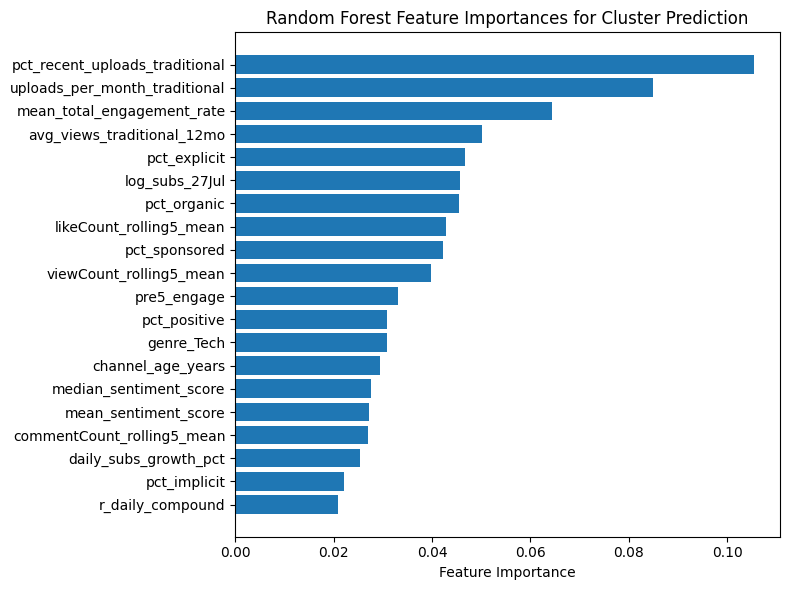

In [16]:
#Random Forest Feature Importance and SHAP
X_df = pd.DataFrame(X_preprocessed, columns=all_feature_names)
y = df6['cluster_4'].values

print("X_df shape:", X_df.shape)
print("y shape:", y.shape)

# 1. Fit Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_df, y)

# 2. Show classification report (optional, just to check accuracy)
y_pred = rf.predict(X_df)
print(classification_report(y, y_pred))

# 3. Feature importances (top 20 for display)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Top 20

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices][::-1], align='center')
plt.yticks(range(len(indices)), [all_feature_names[i] for i in indices][::-1])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances for Cluster Prediction')
plt.tight_layout()
plt.show()

In [17]:
import shap

# Create explainer using your trained model
explainer = shap.TreeExplainer(rf)

# Compute SHAP values
shap_values = explainer.shap_values(X_df)

# Now check shapes
print(type(shap_values))
print(len(shap_values))   # useful for classification

print(shap_values[0].shape)
print(X_df.shape)

<class 'numpy.ndarray'>
2308
(52, 4)
(2308, 52)


In [18]:

# ---- 6. [Optional] Regression for Long-term Effects ----

import statsmodels.api as sm

# Does sponsorship explain sub growth (by cluster)?
for k in [3, 4]:
    dfc = df6.copy()
    X_reg = dfc[['pct_explicit', 'pct_sponsored', 'pct_implicit', f'cluster_{k}']]
    X_reg = sm.add_constant(X_reg)
    y_reg = dfc['daily_subs_growth_pct']
    model = sm.OLS(y_reg, X_reg).fit()
    print(f"\nOLS Regression Results for Sub Growth by Sponsorship and Cluster (K={k}):")
    print(model.summary())

# ---- 7. Business Insight/Recommendation Table ----
for k in [3, 4]:
    print(f"\nSummary for Cluster_{k}")
    for c in sorted(df6[f'cluster_{k}'].unique()):
        sub = df6[df6[f'cluster_{k}'] == c]
        print(f"\nCluster {c} | N={len(sub)}")
        print("Size:", sub['sizeCategory'].value_counts(normalize=True).round(2).to_dict())
        print("Genre:", sub['genre'].value_counts(normalize=True).round(2).to_dict())
        print("Sponsorship:", sub['Sponsorship'].value_counts(normalize=True).round(2).to_dict())
        print("Mean Engagement Rate:", sub['total_engagement_rate'].mean().round(3))
        print("Mean Sentiment:", sub['mean_sentiment_score'].mean().round(3))
        print("Mean Sub Growth:", sub['daily_subs_growth_pct'].mean().round(4))
        # add more insights as needed!


OLS Regression Results for Sub Growth by Sponsorship and Cluster (K=3):
                              OLS Regression Results                             
Dep. Variable:     daily_subs_growth_pct   R-squared:                       0.178
Model:                               OLS   Adj. R-squared:                  0.177
Method:                    Least Squares   F-statistic:                     125.0
Date:                   Mon, 23 Mar 2026   Prob (F-statistic):           1.05e-96
Time:                           14:41:39   Log-Likelihood:                 10502.
No. Observations:                   2308   AIC:                        -2.099e+04
Df Residuals:                       2303   BIC:                        -2.097e+04
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

**RESEARCH 6**

In [19]:
print('channel data columns',channel.columns)
print('master data columns',data.columns)
print('dataframe 6',df6.columns)

channel data columns Index(['channelId', 'name', 'genre', 'sizeCategory', 'title', 'channelUrl',
       'channelCreationDate', 'videosInLast6Months', 'videoCount', 'viewCount',
       'description', 'country', 'channel_age_years', 'traditional_videos_6mo',
       'shorts_videos_6mo', 'total_videos_6mo', 'pct_traditional_12mo',
       'pct_shorts_6mo', 'uploads_per_month_traditional',
       'pct_recent_uploads_traditional', 'avg_views_per_video',
       'avg_views_traditional_12mo', 'subscriber_growth_pct', 'log_videoCount',
       'log_viewCount', 'log_traditional_videos_12mo', 'log_shorts_videos_6mo',
       'num_sponsored_videos', 'num_explicit_videos', 'num_implicit_videos',
       'num_organic_videos', 'first_sponsor_date_channel',
       'has_sponsorship_history', 'pct_sponsored', 'pct_explicit',
       'pct_implicit', 'pct_organic', 'mean_viewCount', 'median_viewCount',
       'mean_likeCount', 'mean_commentCount', 'mean_total_engagement_rate',
       'mean_sentiment_score', 'do

Cluster Profiling for Strategy Optimization

,total_engagement_rate,mean_sentiment_score,daily_subs_growth_pct,pct_sponsored,pct_explicit,pct_implicit,pct_organic
cluster_4,,,,,,,
0,0.033,0.772,0.001,0.845,0.154,0.691,0.155
1,0.039,0.800,0.002,0.841,0.547,0.293,0.159
2,0.145,0.836,0.004,0.955,0.927,0.028,0.045
3,0.065,0.905,0.005,0.585,0.251,0.334,0.415


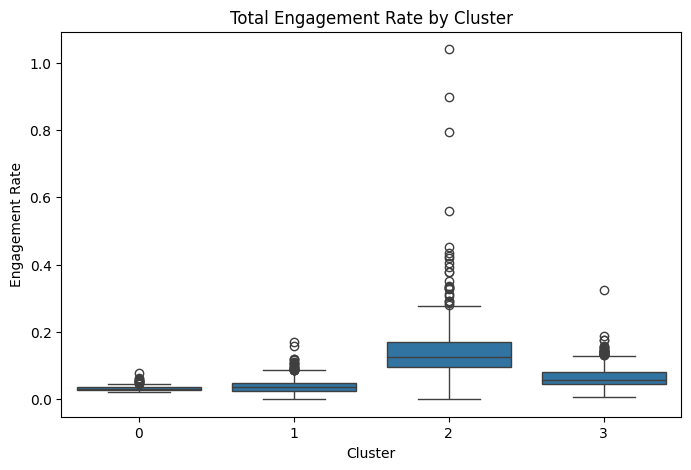

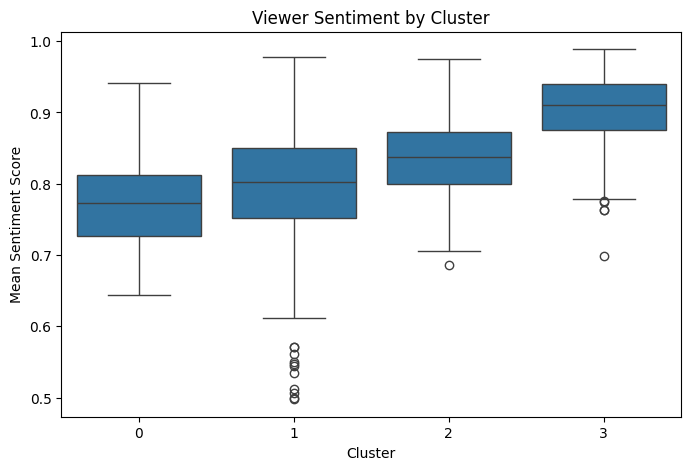

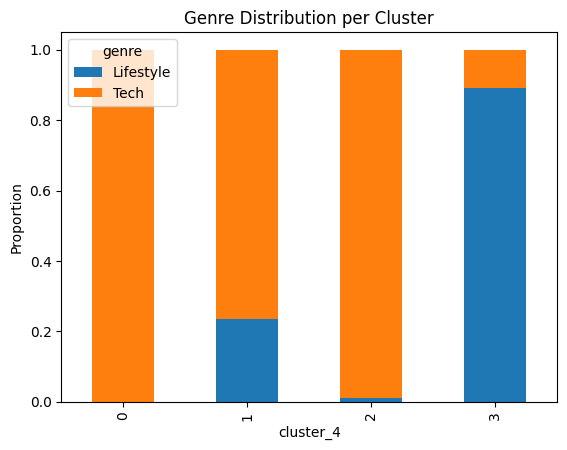

In [20]:
# Assume df6 is your cluster-level DataFrame (with 'cluster_4', etc.)
# We'll focus on cluster_4 for rich profiling

# 1. Profile key engagement/authenticity metrics by cluster
profile_cols = [
    'total_engagement_rate', 'mean_sentiment_score', 'daily_subs_growth_pct',
    'pct_sponsored', 'pct_explicit', 'pct_implicit', 'pct_organic'
]
grouped = df6.groupby('cluster_4')[profile_cols].mean().round(3)
display(grouped)

# 2. Plot: Engagement rate by cluster (boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(x='cluster_4', y='total_engagement_rate', data=df6)
plt.title("Total Engagement Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Engagement Rate")
plt.show()

# 3. Plot: Sentiment score by cluster (boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(x='cluster_4', y='mean_sentiment_score', data=df6)
plt.title("Viewer Sentiment by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean Sentiment Score")
plt.show()

# 4. Cluster composition by genre/size (stacked bar)
genre_counts = pd.crosstab(df6['cluster_4'], df6['genre'], normalize='index')
genre_counts.plot(kind='bar', stacked=True)
plt.title('Genre Distribution per Cluster')
plt.ylabel('Proportion')
plt.show()


Sponsorship Fatigue: Is “Too Much” Sponsorship Harmful?

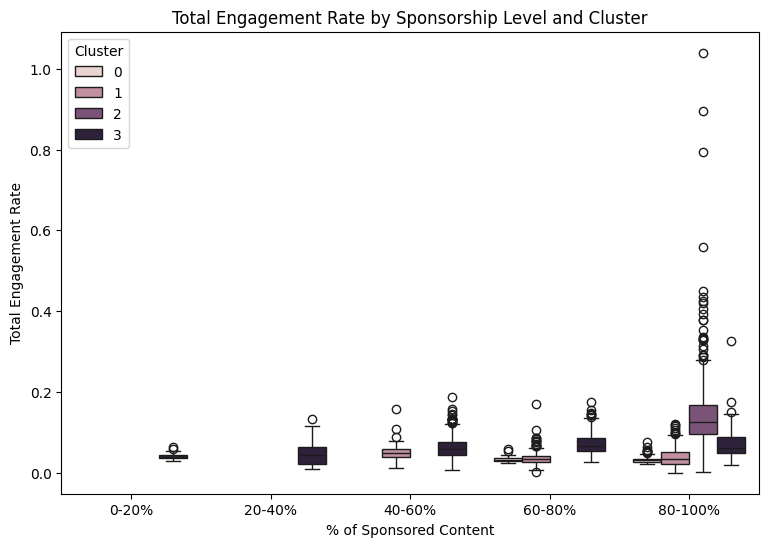

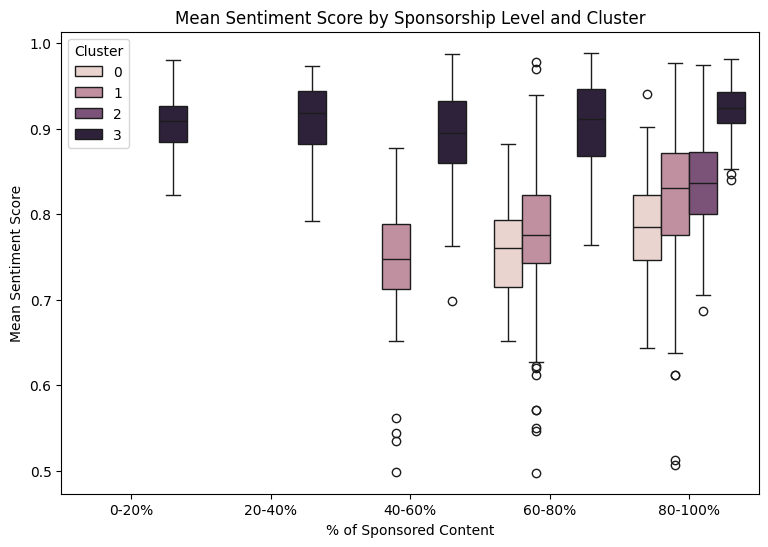

In [21]:
# Bin by pct_sponsored (channel/video-level; use channel if available)
df6['sponsored_bin'] = pd.cut(df6['pct_sponsored'], bins=[0,0.2,0.4,0.6,0.8,1], labels=["0-20%","20-40%","40-60%","60-80%","80-100%"])

# Plot engagement and sentiment vs. sponsorship bin, faceted by cluster
for metric in ['total_engagement_rate', 'mean_sentiment_score']:
    plt.figure(figsize=(9,6))
    sns.boxplot(x='sponsored_bin', y=metric, hue='cluster_4', data=df6)
    plt.title(f'{metric.replace("_"," ").title()} by Sponsorship Level and Cluster')
    plt.xlabel('% of Sponsored Content')
    plt.ylabel(metric.replace('_',' ').title())
    plt.legend(title='Cluster')
    plt.show()


SHAP (Explainable ML): What Drives Engagement/Sub Growth?

 97%|=================== | 2228/2308 [00:24<00:00]       

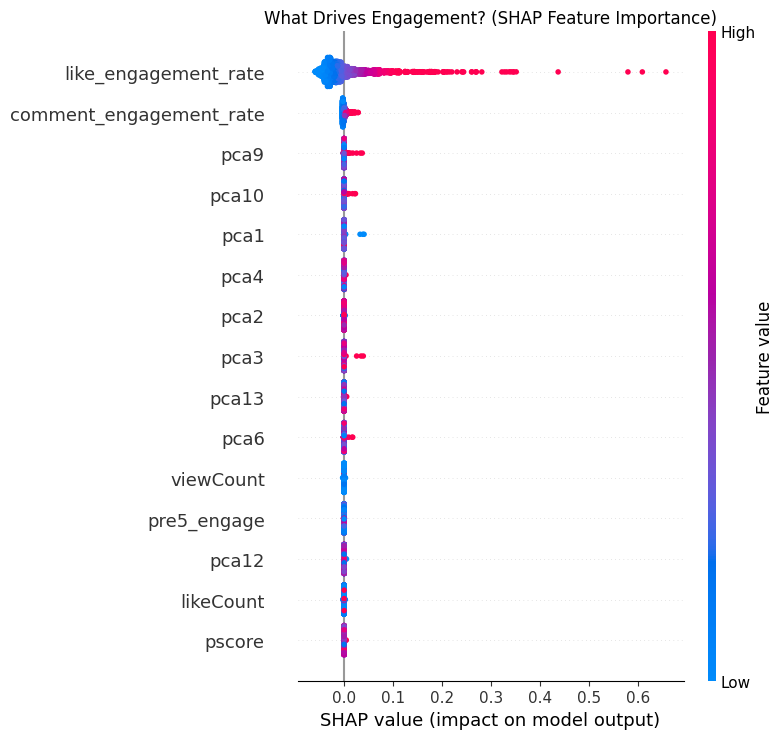

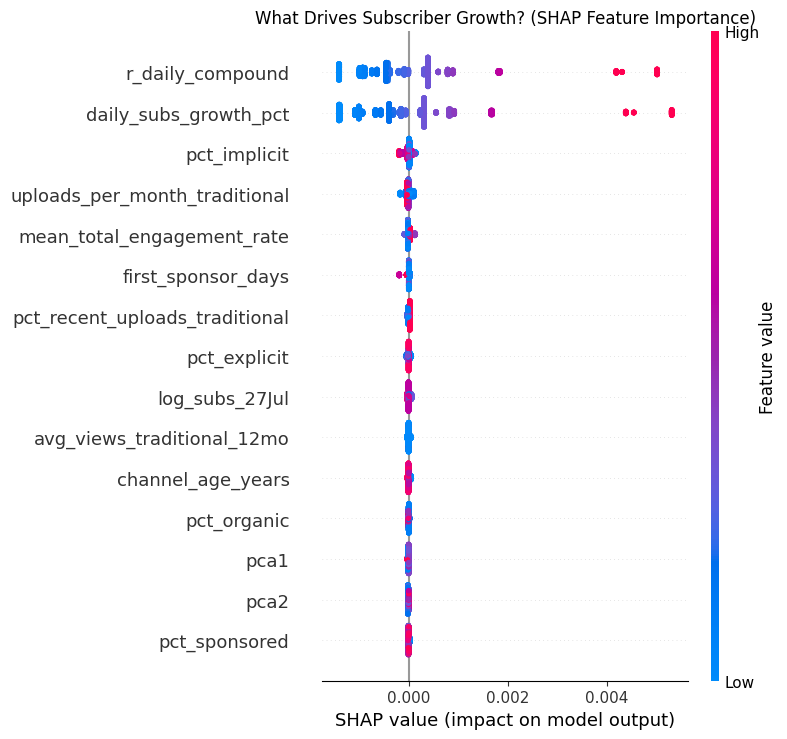

In [22]:
import shap
from sklearn.ensemble import RandomForestRegressor

# For engagement
features = [col for col in df6.columns if col not in ['total_engagement_rate','mean_sentiment_score','cluster_4','sponsored_bin']]
X = df6[features].select_dtypes(include=[np.number]).fillna(0)
y = df6['total_engagement_rate']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

explainer = shap.Explainer(rf, X)
shap_values = explainer(X)

# Plot summary of SHAP (which features matter most)
shap.summary_plot(shap_values, X, max_display=15, show=False)
plt.title("What Drives Engagement? (SHAP Feature Importance)")
plt.tight_layout()
plt.show()

# Repeat for sub growth (if desired)
y2 = df6['daily_subs_growth_pct']
rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf2.fit(X, y2)
explainer2 = shap.Explainer(rf2, X)
shap_values2 = explainer2(X)
shap.summary_plot(shap_values2, X, max_display=15, show=False)
plt.title("What Drives Subscriber Growth? (SHAP Feature Importance)")
plt.tight_layout()
plt.show()


SHAP Feature Importance Within Each Cluster


=== SHAP Analysis for Cluster 0 ===

Target: total_engagement_rate


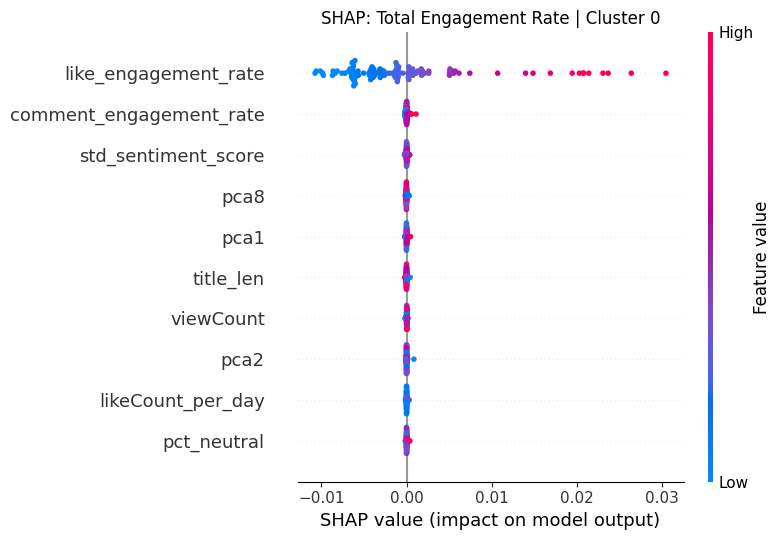


Target: mean_sentiment_score


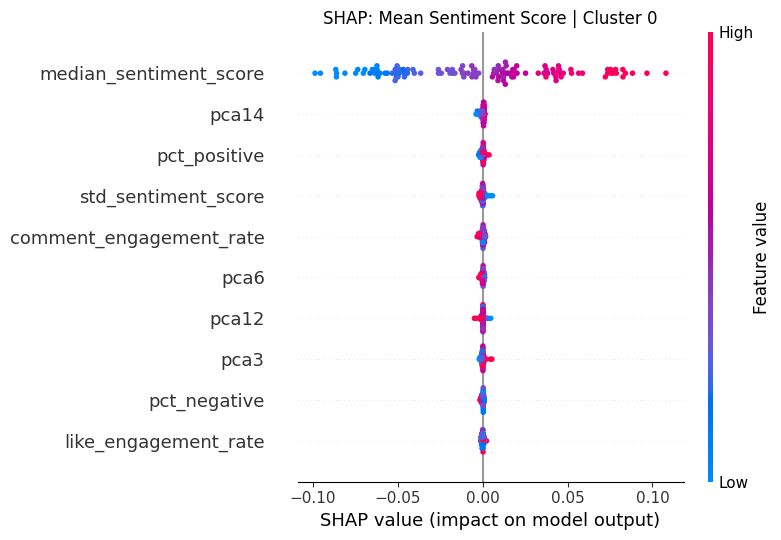


Target: daily_subs_growth_pct


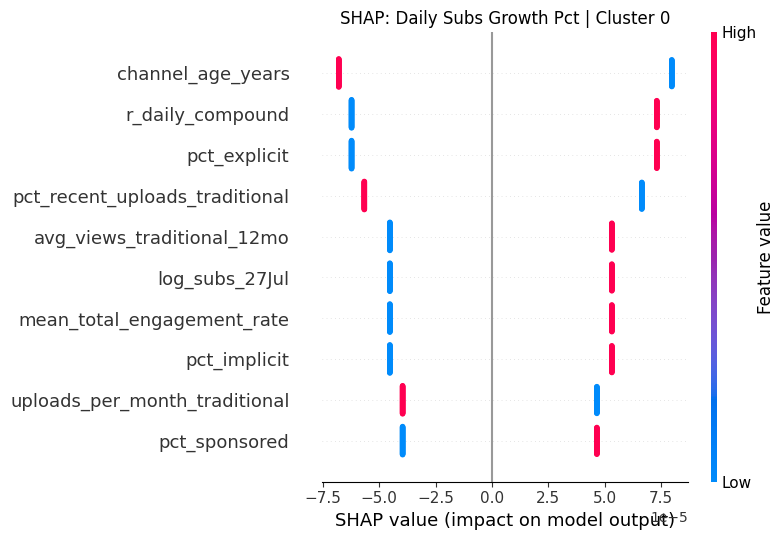


=== SHAP Analysis for Cluster 1 ===

Target: total_engagement_rate


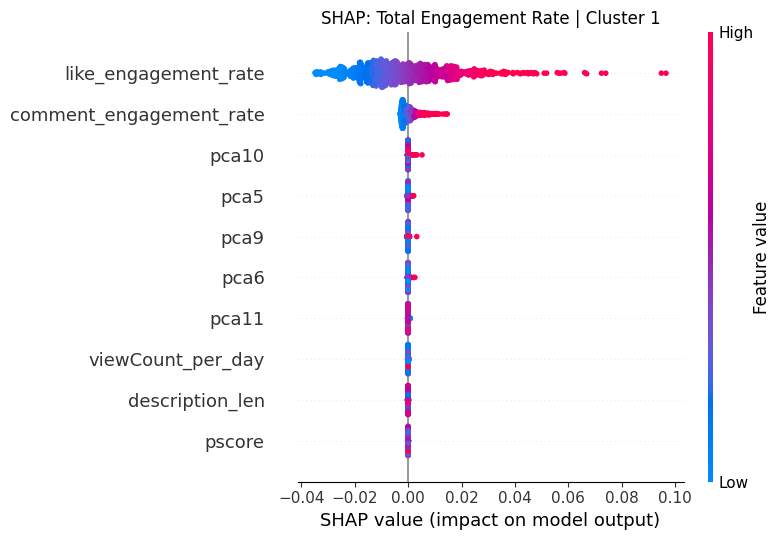


Target: mean_sentiment_score


 97%|=================== | 1049/1087 [00:15<00:00]       

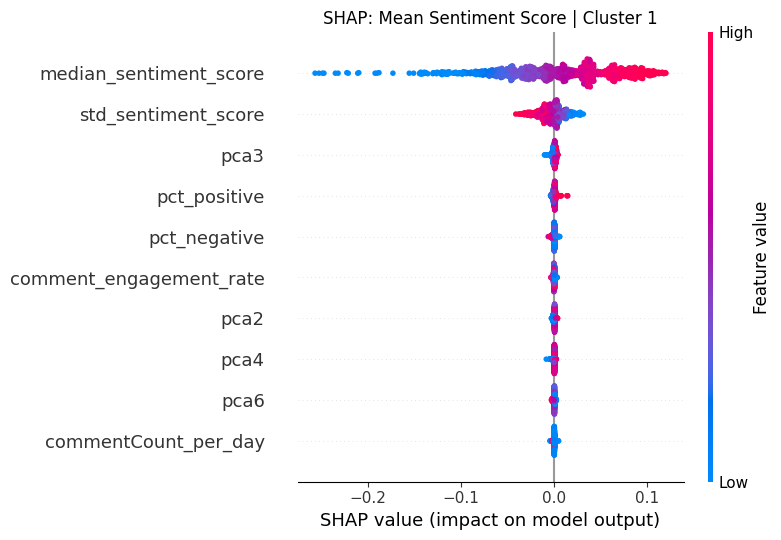


Target: daily_subs_growth_pct


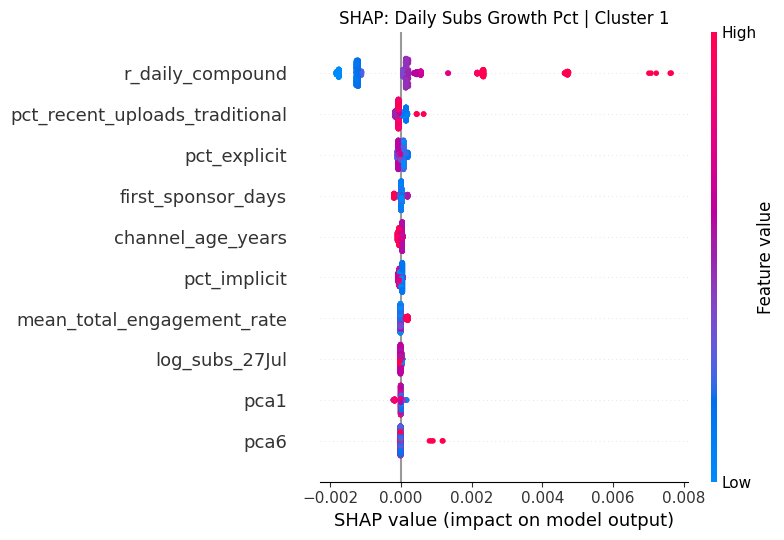


=== SHAP Analysis for Cluster 2 ===

Target: total_engagement_rate


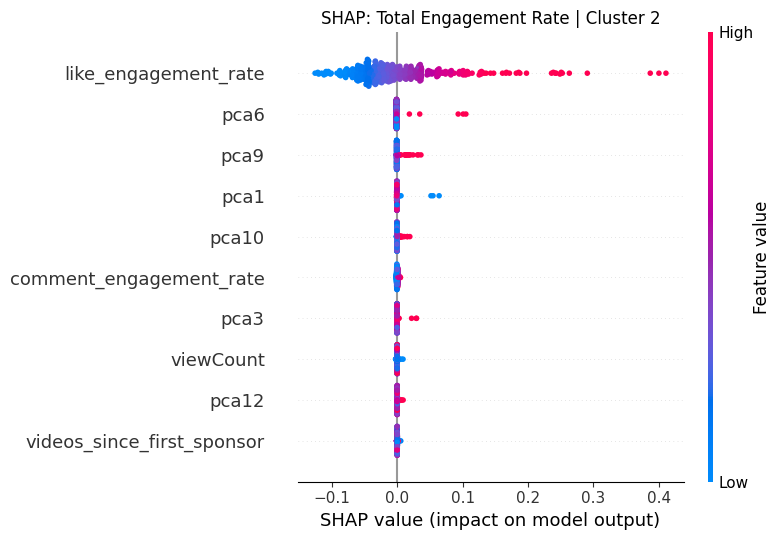


Target: mean_sentiment_score


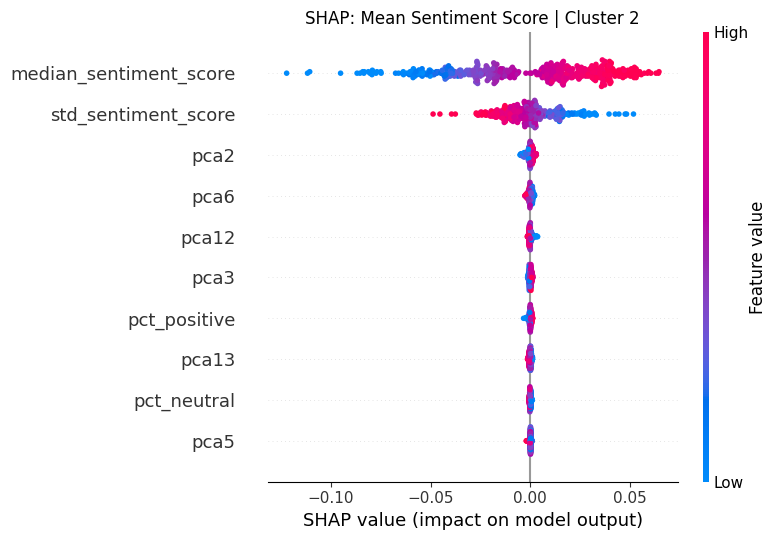


Target: daily_subs_growth_pct


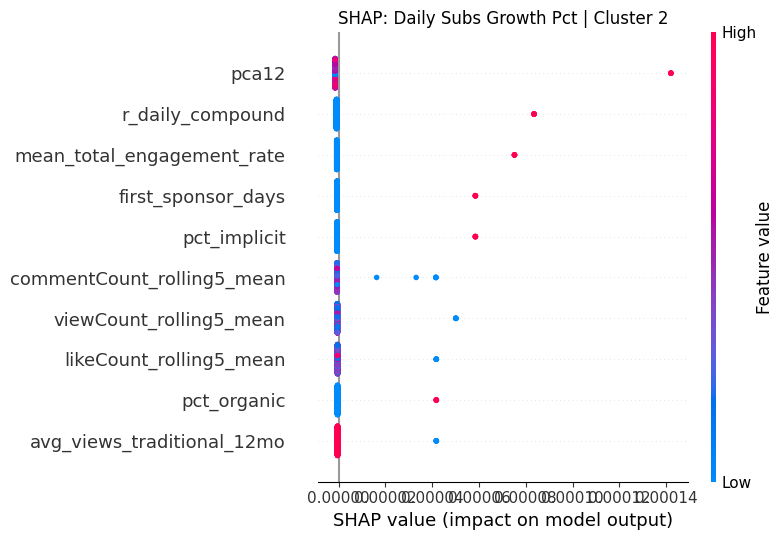


=== SHAP Analysis for Cluster 3 ===

Target: total_engagement_rate


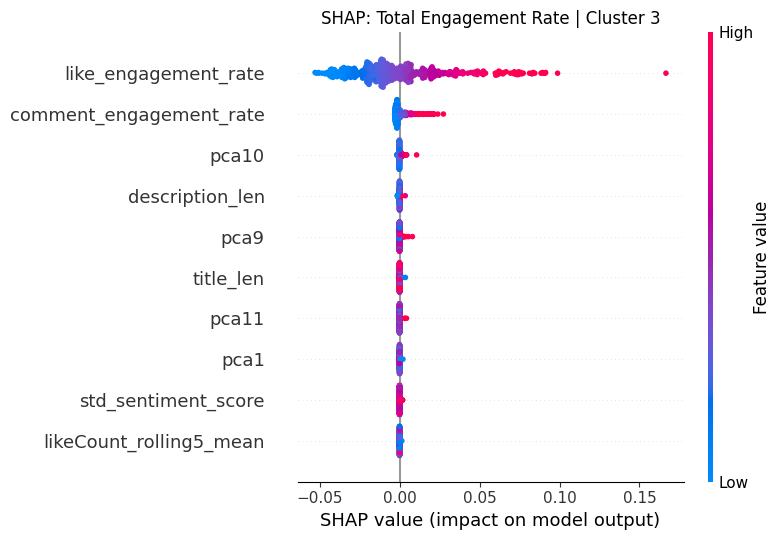


Target: mean_sentiment_score


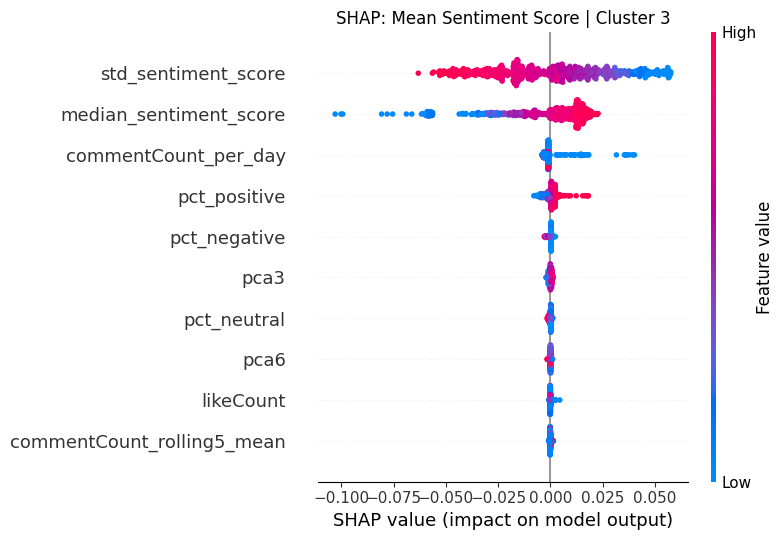


Target: daily_subs_growth_pct


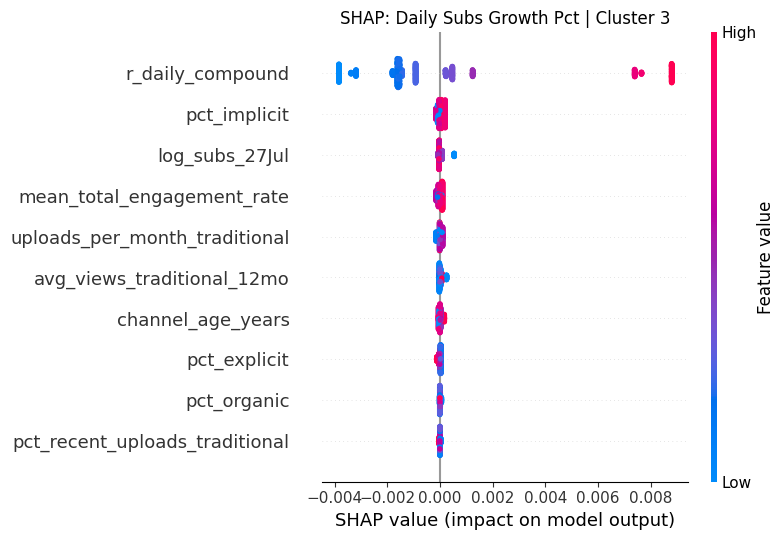

Top 10 features for this cluster and target:
r_daily_compound: 0.974
log_subs_27Jul: 0.005
pct_implicit: 0.005
uploads_per_month_traditional: 0.004
mean_total_engagement_rate: 0.004
channel_age_years: 0.003
avg_views_traditional_12mo: 0.003
pct_explicit: 0.001
pct_recent_uploads_traditional: 0.000
commentCount_rolling5_mean: 0.000


In [23]:
import shap
from sklearn.ensemble import RandomForestRegressor

# Define the clusters and target metrics to analyze
clusters = sorted(df6['cluster_4'].unique())
target_metrics = ['total_engagement_rate', 'mean_sentiment_score', 'daily_subs_growth_pct']

for cluster in clusters:
    print(f"\n=== SHAP Analysis for Cluster {cluster} ===")
    df_cluster = df6[df6['cluster_4'] == cluster].copy()
    # Remove the columns not suitable as features
    feature_cols = [col for col in df_cluster.columns if col not in [
        'total_engagement_rate', 'mean_sentiment_score', 'daily_subs_growth_pct',
        'cluster_4', 'sponsored_bin'
    ]]
    X = df_cluster[feature_cols].select_dtypes(include=[float, int]).fillna(0)

    for target in target_metrics:
        y = df_cluster[target]
        # Skip if not enough variance
        if y.nunique() <= 1:
            print(f"Skipping {target} for Cluster {cluster} (not enough variance).")
            continue
        print(f"\nTarget: {target}")
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)
        explainer = shap.Explainer(rf, X)
        shap_values = explainer(X)
        shap.summary_plot(shap_values, X, max_display=10, show=False)
        plt.title(f"SHAP: {target.replace('_',' ').title()} | Cluster {cluster}")
        plt.tight_layout()
        plt.show()

importances = rf.feature_importances_
top_idx = np.argsort(importances)[::-1][:10]
print("Top 10 features for this cluster and target:")
for i in top_idx:
    print(f"{X.columns[i]}: {importances[i]:.3f}")


In [24]:
import numpy as np
import shap

# targets to analyze
targets = ['total_engagement_rate', 'mean_sentiment_score', 'daily_subs_growth_pct']
n_clusters = df6['cluster_4'].nunique()
n_top = 10  # top N features

# IMPORTANT: You must already have run SHAP explainer within each cluster for each target!

# Assume you have:
#   cluster_dfs = {c: df6[df6['cluster_4']==c] for c in range(n_clusters)}
#   explainer_engagement, explainer_sentiment, explainer_sub_growth for each cluster

for target in targets:
    print(f"\n==== Top Features for {target.replace('_', ' ').title()} per Cluster ====")
    for c in range(n_clusters):
        # subset data
        dfi = df6[df6['cluster_4'] == c]
        X = dfi.select_dtypes(include=[np.number]).drop(targets + [f'cluster_{n_clusters}'], axis=1, errors='ignore')
        y = dfi[target]

        # Fit and explain (Random Forest for example)
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)
        explainer = shap.Explainer(rf, X)
        shap_values = explainer(X)

        # Get mean absolute SHAP values for each feature
        mean_shap = np.abs(shap_values.values).mean(axis=0)
        top_idx = np.argsort(mean_shap)[::-1][:n_top]
        top_feats = X.columns[top_idx]
        top_vals = mean_shap[top_idx]

        print(f"\nCluster {c} ({len(dfi)} rows):")
        for feat, val in zip(top_feats, top_vals):
            print(f"{feat}: {val:.3f}")



==== Top Features for Total Engagement Rate per Cluster ====

Cluster 0 (121 rows):
like_engagement_rate: 0.006
comment_engagement_rate: 0.000
std_sentiment_score: 0.000
pca8: 0.000
pca1: 0.000
title_len: 0.000
viewCount: 0.000
pca2: 0.000
likeCount_per_day: 0.000
pct_neutral: 0.000

Cluster 1 (1087 rows):
like_engagement_rate: 0.014
comment_engagement_rate: 0.002
pca10: 0.000
pca5: 0.000
pca9: 0.000
pca6: 0.000
pca11: 0.000
viewCount_per_day: 0.000
description_len: 0.000
pscore: 0.000

Cluster 2 (473 rows):
like_engagement_rate: 0.052
pca6: 0.002
pca9: 0.001
pca1: 0.001
pca10: 0.001
comment_engagement_rate: 0.001
pca3: 0.000
viewCount: 0.000
pca12: 0.000
videos_since_first_sponsor: 0.000

Cluster 3 (627 rows):
like_engagement_rate: 0.022
comment_engagement_rate: 0.003
pca10: 0.000
description_len: 0.000
pca9: 0.000
title_len: 0.000
pca11: 0.000
pca1: 0.000
std_sentiment_score: 0.000
likeCount_rolling5_mean: 0.000

==== Top Features for Mean Sentiment Score per Cluster ====

Cluster 0

 96%|=================== | 1044/1087 [00:15<00:00]       


Cluster 1 (1087 rows):
median_sentiment_score: 0.051
std_sentiment_score: 0.009
pca3: 0.001
pct_positive: 0.001
pct_negative: 0.001
comment_engagement_rate: 0.001
pca2: 0.001
pca4: 0.001
pca6: 0.001
commentCount_per_day: 0.000

Cluster 2 (473 rows):
median_sentiment_score: 0.032
std_sentiment_score: 0.010
pca2: 0.001
pca6: 0.001
pca12: 0.000
pca3: 0.000
pct_positive: 0.000
pca13: 0.000
pct_neutral: 0.000
pca5: 0.000

Cluster 3 (627 rows):
std_sentiment_score: 0.024
median_sentiment_score: 0.016
commentCount_per_day: 0.003
pct_positive: 0.002
pct_negative: 0.001
pca3: 0.000
pct_neutral: 0.000
pca6: 0.000
likeCount: 0.000
commentCount_rolling5_mean: 0.000

==== Top Features for Daily Subs Growth Pct per Cluster ====

Cluster 0 (121 rows):
channel_age_years: 0.000
r_daily_compound: 0.000
pct_explicit: 0.000
pct_recent_uploads_traditional: 0.000
avg_views_traditional_12mo: 0.000
log_subs_27Jul: 0.000
mean_total_engagement_rate: 0.000
pct_implicit: 0.000
uploads_per_month_traditional: 0.00

In [25]:
# Profile means by cluster
cluster_profile = df6.groupby('cluster_4')[[
    'total_engagement_rate', 'mean_sentiment_score', 'daily_subs_growth_pct',
    'pct_sponsored', 'pct_explicit', 'pct_implicit', 'pct_organic'
]].mean().round(3)

# Genre and size distributions
genre_dist = pd.crosstab(df6['cluster_4'], df6['genre'], normalize='index').round(2)
size_dist = pd.crosstab(df6['cluster_4'], df6['sizeCategory'], normalize='index').round(2)

print("\n=== Cluster Profiles ===")
print(cluster_profile)
print("\n=== Genre Distribution per Cluster ===")
print(genre_dist)
print("\n=== Size Distribution per Cluster ===")
print(size_dist)



=== Cluster Profiles ===
           total_engagement_rate  mean_sentiment_score  daily_subs_growth_pct  \
cluster_4                                                                       
0                          0.033                 0.772                  0.001   
1                          0.039                 0.800                  0.002   
2                          0.145                 0.836                  0.004   
3                          0.065                 0.905                  0.005   

           pct_sponsored  pct_explicit  pct_implicit  pct_organic  
cluster_4                                                          
0                  0.845         0.154         0.691        0.155  
1                  0.841         0.547         0.293        0.159  
2                  0.955         0.927         0.028        0.045  
3                  0.585         0.251         0.334        0.415  

=== Genre Distribution per Cluster ===
genre      Lifestyle  Tech
cluster_4   

In [26]:
for c in range(n_clusters):
    print(f"\n--- Recommendations for Cluster {c} ---")
    metrics = cluster_profile.loc[c]
    genres = genre_dist.loc[c].sort_values(ascending=False)
    sizes = size_dist.loc[c].sort_values(ascending=False)

    print(f"Top genres: {', '.join(genres[genres>0].index)}")
    print(f"Top size categories: {', '.join(sizes[sizes>0].index)}")
    print(f"Engagement rate: {metrics['total_engagement_rate']}, Sentiment: {metrics['mean_sentiment_score']}, Sub growth: {metrics['daily_subs_growth_pct']}")
    print(f"Sponsorship split: Explicit={metrics['pct_explicit']:.2f}, Implicit={metrics['pct_implicit']:.2f}, Organic={metrics['pct_organic']:.2f}")

    # Example recommendations
    if metrics['pct_explicit'] > 0.5:
        print("- High explicit sponsorship: Continue transparent disclosures, but monitor for sentiment/engagement trade-off.")
    if metrics['total_engagement_rate'] > 0.1:
        print("- High engagement: Maintain current content strategy, focus on like/comment engagement drivers (see SHAP).")
    # (add more logic as needed)

    # Print top SHAP drivers from above code
    # For brevity, assume you’ve stored those in a dict: top_features_per_cluster_target[cluster][target]
    # Example:
    # print("Top drivers of engagement:", ', '.join(top_features_per_cluster_target[c]['total_engagement_rate']))



--- Recommendations for Cluster 0 ---
Top genres: Tech
Top size categories: Macro
Engagement rate: 0.033, Sentiment: 0.772, Sub growth: 0.001
Sponsorship split: Explicit=0.15, Implicit=0.69, Organic=0.15

--- Recommendations for Cluster 1 ---
Top genres: Tech, Lifestyle
Top size categories: Micro, Macro, Nano
Engagement rate: 0.039, Sentiment: 0.8, Sub growth: 0.002
Sponsorship split: Explicit=0.55, Implicit=0.29, Organic=0.16
- High explicit sponsorship: Continue transparent disclosures, but monitor for sentiment/engagement trade-off.

--- Recommendations for Cluster 2 ---
Top genres: Tech, Lifestyle
Top size categories: Micro, Nano
Engagement rate: 0.145, Sentiment: 0.836, Sub growth: 0.004
Sponsorship split: Explicit=0.93, Implicit=0.03, Organic=0.04
- High explicit sponsorship: Continue transparent disclosures, but monitor for sentiment/engagement trade-off.
- High engagement: Maintain current content strategy, focus on like/comment engagement drivers (see SHAP).

--- Recommendati